Dependencies

In [1]:
from tensorflow import keras
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import os
from datetime import datetime

Helper Functions

In [ ]:
def output_data(data):
    print(data.head())
    print(data.info())
    print(data.describe())

def visualize_data(data):
    # Initial Data Visualization
    # Plot 1 - Open and Close prices of time 
    plt.figure(figsize=(12,6))
    plt.plot(data['date'], data['open'], label="Open",color = "blue")
    plt.plot(data['date'], data['close'], label="Close",color = "red")
    plt.title("Open-Close Price over Time")
    plt.legend()
    plt.show()

    # Plot 2 - Trading Volume(check for outliers)
    plt.figure(figsize=(12,6))
    plt.plot(data['date'], data['volume'], label="Volume",color="orange")
    plt.title("Stock Volume over Time")
    plt.show()

def visualize_prediction(data):
    plt.figure(figsize=(12,6))
    plt.plot(data['date'], data['close'],color="blue")
    plt.xlabel("Date")
    plt.ylabel("Close")
    plt.title("Price over time")

def visualize_num_correlations(num_data):
    # Plot 3 - Check for correlation between features
    plt.figure(figsize=(8,6))
    sns.heatmap(num_data.corr(), annot=True, cmap="coolwarm")
    plt.title("Feature Correlation Heatmap")
    plt.show()

/Users/artyomk/dev/projects/market-mind/venv/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 58,369 (228.00 KB)

 Trainable params: 58,369 (228.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.6717 - root_mean_squared_error: 1.0028
Epoch 2/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.6720 - root_mean_squared_error: 1.0023
Epoch 3/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.6692 - root_mean_squared_error: 1.0016
Epoch 4/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.6710 - root_mean_squared_error: 1.0019
Epoch 5/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.6703 - root_mean_squared_error: 1.0003
Epoch 6/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.6699 - root_mean_squared_error: 0.9984
Epoch 7/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.6712 - root_mean_squared_error: 1.0019
Epoch 8/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.6715 - root_mean_squared_error: 1.0005
Epoch 9/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.6692 - root_mean_squared_error: 0.9997
Epoch 10/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.6704 - root_mean_squared_err

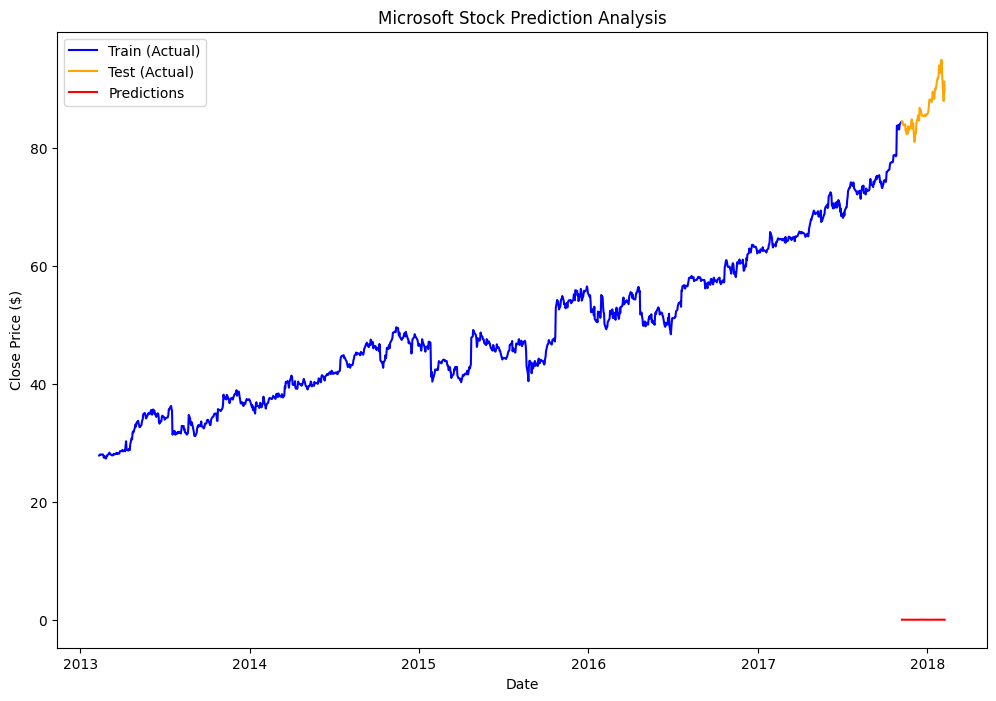

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from sklearn.preprocessing import StandardScaler
from tensorflow import keras

# ==========================================
# 1. DATA LOADING & PREPROCESSING
# ==========================================
data = pd.read_csv("MicrosoftStock.csv")
data['date'] = pd.to_datetime(data['date'])

# Feature Engineering: Calculate daily returns instead of raw price
data['return'] = data['close'].pct_change()

# Clean data: Remove the first NaN row resulting from pct_change()
data = data.dropna()

# Filtering specific columns for the model
stock_close = data.filter(["return"])
dataset = stock_close.values

# ==========================================
# 2. DATA SPLITTING (TRAIN/TEST)
# ==========================================
training_data_len = int(np.ceil(len(dataset)) * 0.95)
training_data_raw = dataset[:training_data_len]
test_data_raw = dataset[training_data_len - 60:]

# ==========================================
# 3. FEATURE SCALING
# ==========================================
scaler = StandardScaler()
scaled_data = scaler.fit_transform(dataset[:training_data_len])
# Ensure we only use the scaled training portion
training_data = scaled_data

# ==========================================
# 4. SLIDING WINDOW DATA PREPARATION (X, y)
# ==========================================
X_train, y_train = [], []

# Create sequences of 60 days to predict the 61st day
for i in range(60, len(training_data)):
    X_train.append(training_data[i-60:i, 0])
    y_train.append(training_data[i, 0])

X_train, y_train = np.array(X_train), np.array(y_train)

# Reshape for LSTM: [samples, time steps, features]
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))

# ==========================================
# 5. MODEL ARCHITECTURE (LSTM)
# ==========================================
model = keras.models.Sequential([
    # Input/First LSTM Layer
    keras.layers.LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], 1)),
    
    # Second LSTM Layer (return_sequences=False because the next layer is Dense)
    keras.layers.LSTM(64, return_sequences=False),
    
    # Fully Connected Layers
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dropout(0.5), # Prevents overfitting
    
    # Output Layer
    keras.layers.Dense(1)
])

# ==========================================
# 6. COMPILATION & TRAINING
# ==========================================
model.compile(optimizer="adam",
              loss="mae", 
              metrics=[keras.metrics.RootMeanSquaredError()])

model.summary()

training = model.fit(X_train, y_train, epochs=100, batch_size=32)

# ==========================================
# 7. FORECASTING / PREDICTION LOOP
# ==========================================
# Scale test data using the same scaler from training
test_data_scaled = scaler.transform(test_data_raw) 

current_batch = test_data_scaled[:60]
current_batch = current_batch.reshape((1, 60, 1)) 

predicted_prices = []
days_to_predict = len(test_data_scaled) - 60

# Recursive prediction: use the model's own output to predict the next day
for i in range(days_to_predict):
    current_pred = model.predict(current_batch, verbose=0)[0]
    predicted_prices.append(current_pred) 
    
    # Update the window: drop the first entry, append the new prediction
    current_batch = np.append(current_batch[:, 1:, :], [[current_pred]], axis=1)

# Invert scaling to get actual return values
predictions = scaler.inverse_transform(predicted_prices)

# ==========================================
# 8. VISUALIZATION & EVALUATION
# ==========================================
train = data[:training_data_len]
test = data[training_data_len:].copy()
test['Predictions'] = predictions

plt.figure(figsize=(12,8))
plt.plot(train['date'], train['close'], label="Train (Actual)", color='blue')
plt.plot(test['date'], test['close'], label="Test (Actual)", color='orange')
plt.plot(test['date'], test['Predictions'], label="Predictions", color='red')
plt.title("Microsoft Stock Prediction Analysis")
plt.xlabel("Date")
plt.ylabel("Close Price ($)")
plt.legend()
plt.show()